In [55]:
#tabella di confronto tra risultati veri e risultati con tutte righe di Balmer a stesso potenziale
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = [
["J0021", 5.324e9, 7.711e-3, 5.466e9, 1.045e-2, "Hb, Hd, Hg", "Aumentano (Mbh poco) (diventa SS)"],
["J0050", 2.344e8, 4.407e-3, 2.261e8, 5.999e-3, "Ha, Hb, Hd, Hg", "Mbh diminuisce (poco), mdot cresce"],
["J0059", 2.244e8, 1.336e-2, 3.079e8, 3.461e-2, "MgII, Hd, Hg", "Aumentano"],
["J0133", 1.145e8, 1.670e-2, 9.033e8, 2.154e-2, "MgII, Hd", "Aumentano"],
["J0508", 5.947e5, 1.321e1, 5.947e5, 1.321e1, "CIII, CIV", "NO BALMER! --> rimane ="],
["J0922", 3.608e10, 9.872e-3, 6.243e9, 2.481e-2, "MgII, Hb, Hd, Hg", "Mbh diminuisce (tanto), mdot cresce (SS)"],
["J0922-Hb", 3.088e10, 9.849e-3, 7.658e9, 2.421e-2, "MgII, Hd, Hg", "Mbh diminuisce, mdot cresce (diventa SS)"],
["J1123", 4.008e9, 7.457e-3, 4.928e9, 8.630e-3, "Ha, Hb, Hd, Hg", "Aumentano"],
["J1329", 2.758e10, 9.881e-3, 5.497e8, 2.093e-2, "MgII, Hd, Hg", "Mbh diminuisce (tanto), mdot cresce (SS)"],
["J1329-Hg", 2.343e8, 1.849e-2, 1.417e8, 5.672e-2, "MgII, Hd", "Mbh diminuisce, mdot cresce"],
["J1745", 2.409e9, 8.126e-3, 3.186e9, 8.331e-3, "Ha, Hb", "Aumentano (poco)"],
["J1816", 3.016e10, 9.577e-3, 3.016e10, 9.577e-3, "MgII, CIII, CIV", "NO BALMER! --> rimane ="],
["J1816-MgII-CIII", 2.657e11, 9.749e-3, 2.657e11, 9.749e-3, "CIV", "NO BALMER! --> rimane ="],
["J2237", 1.750e9, 7.135e-3, 2.009e9, 8.233e-3, "Hb, Hd, Hg", "Aumentano"],
["J152422", 1.169e11, 8.890e-4, 8.099e10, 9.764e-4, "MgII, CIII, Hd", "Mbh diminuisce, mdot cresce"],
["J170108", 4.005e8, 9.353e-3, 4.005e8, 9.353e-3, "MgII, CIII, CIV", "NO BALMER! --> rimane ="],
]

cols = [
"Blazar",
"M_BH",
"m_dot",
"M_BH_13.6",
"m_dot_13.6",
"Righe",
"Commento"
]

df = pd.DataFrame(data, columns=cols)

print("Tabella completa:")
display(df)

Tabella completa:


,Blazar,M_BH,m_dot,M_BH_13.6,m_dot_13.6,Righe,Commento
0,J0021,5.324000e+09,0.007711,5.466000e+09,0.010450,"Hb, Hd, Hg",Aumentano (Mbh poco) (diventa SS)
1,J0050,2.344000e+08,0.004407,2.261000e+08,0.005999,"Ha, Hb, Hd, Hg","Mbh diminuisce (poco), mdot cresce"
2,J0059,2.244000e+08,0.013360,3.079000e+08,0.034610,"MgII, Hd, Hg",Aumentano
3,J0133,1.145000e+08,0.016700,9.033000e+08,0.021540,"MgII, Hd",Aumentano
4,J0508,5.947000e+05,13.210000,5.947000e+05,13.210000,"CIII, CIV",NO BALMER! --> rimane =
5,J0922,3.608000e+10,0.009872,6.243000e+09,0.024810,"MgII, Hb, Hd, Hg","Mbh diminuisce (tanto), mdot cresce (SS)"
6,J0922-Hb,3.088000e+10,0.009849,7.658000e+09,0.024210,"MgII, Hd, Hg","Mbh diminuisce, mdot cresce (diventa SS)"
7,J1123,4.008000e+09,0.007457,4.928000e+09,0.008630,"Ha, Hb, Hd, Hg",Aumentano
8,J1329,2.758000e+10,0.009881,5.497000e+08,0.020930,"MgII, Hd, Hg","Mbh diminuisce (tanto), mdot cresce (SS)"
9,J1329-Hg,2.343000e+08,0.018490,1.417000e+08,0.056720,"MgII, Hd","Mbh diminuisce, mdot cresce"


In [56]:
blazar_13 = [
"J0021",
"J0050",
"J0059",
"J0133",
"J0508",
"J0922-Hb",
"J1123",
"J1329-Hg",
"J1745",
"J1816-MgII-CIII",
"J2237",
"J152422",
"J170108",
]

df13 = df[df["Blazar"].isin(blazar_13)].copy()

df13["Blazar"] = pd.Categorical(
df13["Blazar"],
categories=blazar_13,
ordered=True
)

df13 = df13.sort_values("Blazar").reset_index(drop=True)

#print("Tabella dei 13 blazar usati nel plot:")
#display(df13)

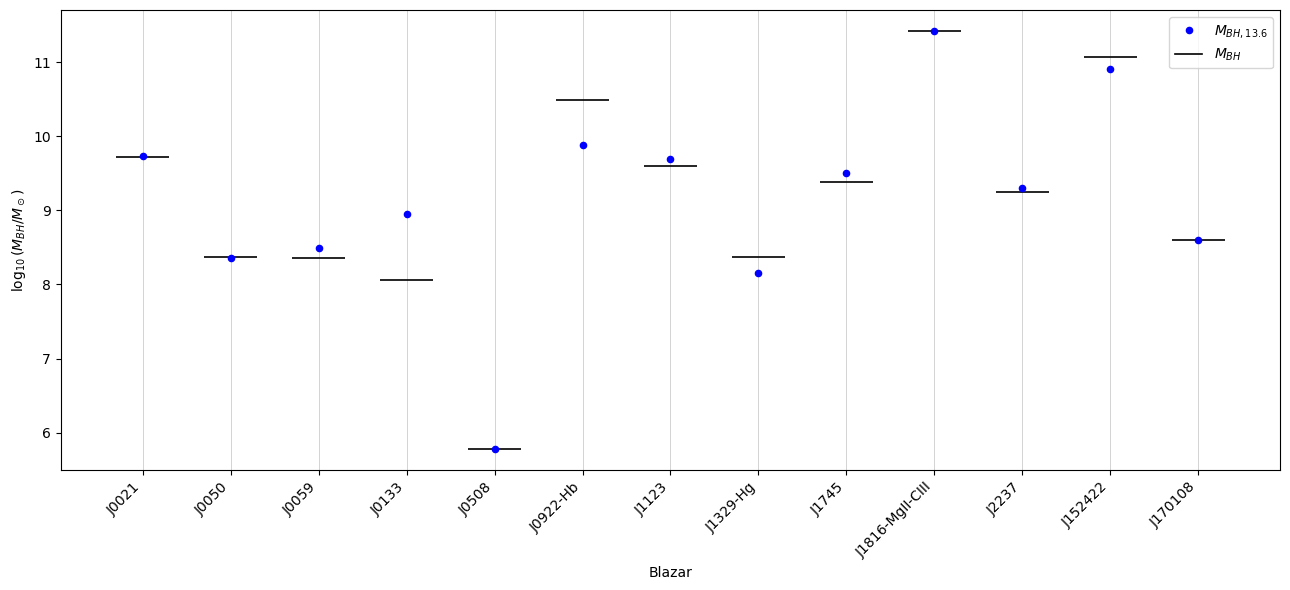

In [57]:
# plot di M_BH vs M_BH_13.6 dando colore diverso a ciascun blazar
import matplotlib.pyplot as plt
point_size = 20
line_width = 1.2
segment_width = 0.30

x = np.arange(len(df13))

plt.figure(figsize=(13, 6))

for xi, mbh in zip(x, df13["M_BH"]):
    plt.hlines(
        y=np.log10(mbh),
        xmin=xi - segment_width,
        xmax=xi + segment_width,
        color="black",
        linewidth=line_width,
        zorder=2
        )

plt.scatter(
    x,
    np.log10(df13["M_BH_13.6"]),
    s=point_size,
    color="blue",
    zorder=3,
    label=r"$M_{BH,13.6}$"
    )

plt.plot(
    [],
    [],
    color="black",
    linewidth=line_width,
    label=r"$M_{BH}$"
    )

plt.xticks(
    x,
    df13["Blazar"],
    rotation=45,
    ha="right",
    )

#plt.ylim(1e9, 1e10)
plt.ylabel(r"$\log_{10}(M_{BH}/M_\odot)$")
plt.xlabel("Blazar")
plt.legend()
for xi in x:
    plt.axvline(
        x=xi,
        color="gray",
        linewidth=0.6,
        alpha=0.4,
        zorder=0
        )
plt.tight_layout()
plt.show()

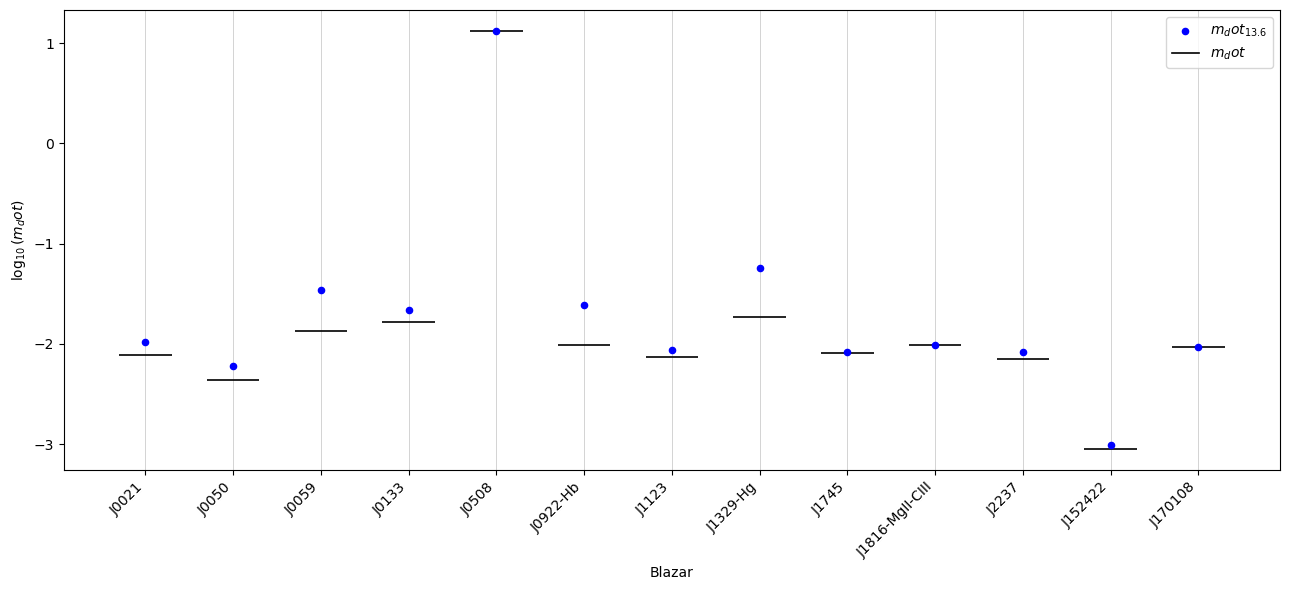

In [58]:
# plot di m_dot vs m_dot_13.6 dando colore diverso a ciascun blazar

import matplotlib.pyplot as plt
point_size = 20
line_width = 1.2
segment_width = 0.30

x = np.arange(len(df13))

plt.figure(figsize=(13, 6))

for xi, mdot in zip(x, df13["m_dot"]):
    plt.hlines(
        y=np.log10(mdot),
        xmin=xi - segment_width,
        xmax=xi + segment_width,
        color="black",
        linewidth=line_width,
        zorder=2
        )

plt.scatter(
    x,
    np.log10(df13["m_dot_13.6"]),
    s=point_size,
    color="blue",
    zorder=3,
    label=r"$m_dot_{13.6}$"
    )

plt.plot(
    [],
    [],
    color="black",
    linewidth=line_width,
    label=r"$m_dot$"
    )

plt.xticks(
    x,
    df13["Blazar"],
    rotation=45,
    ha="right",
    )

#plt.ylim(1e9, 1e10)
plt.ylabel(r"$\log_{10}(m_dot)$")
plt.xlabel("Blazar")
plt.legend()
for xi in x:
    plt.axvline(
        x=xi,
        color="gray",
        linewidth=0.6,
        alpha=0.4,
        zorder=0
        )
plt.tight_layout()
plt.show()

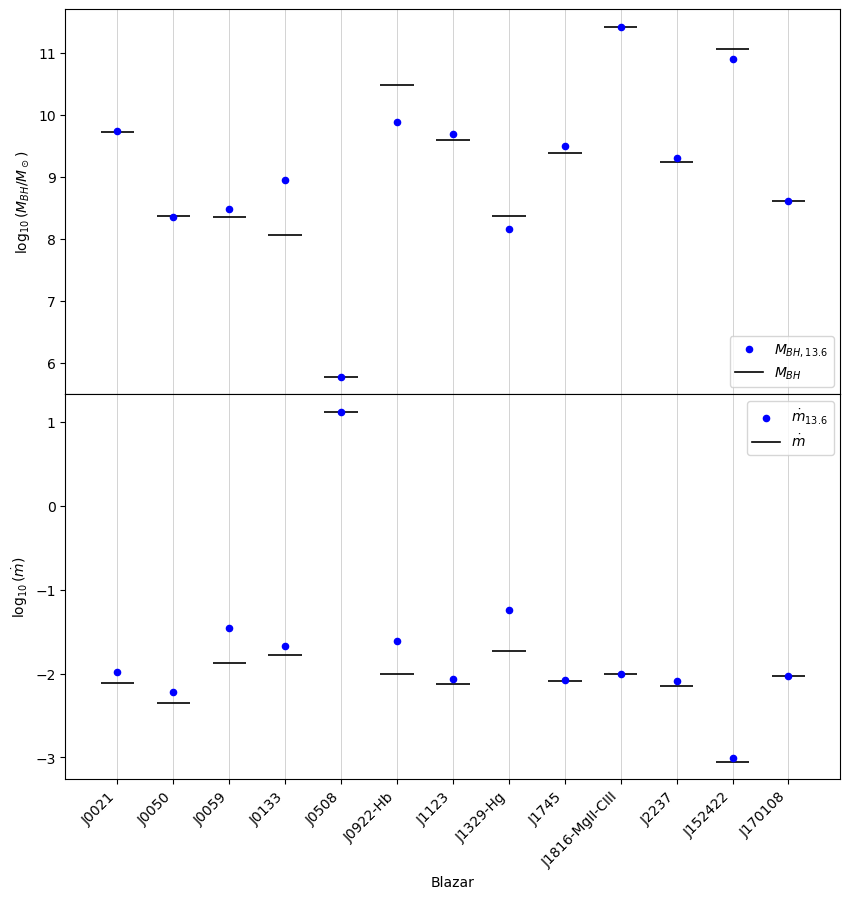

In [59]:
#stampo i due grafici vicini
import matplotlib.pyplot as plt
import numpy as np

point_size = 20
line_width = 1.2
segment_width = 0.30

x = np.arange(len(df13))

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 10),
    sharex=True,
    gridspec_kw={"hspace": 0}
    )

for xi, mbh in zip(x, df13["M_BH"]):
    ax1.hlines(
    y=np.log10(mbh),
    xmin=xi - segment_width,
    xmax=xi + segment_width,
    color="black",
    linewidth=line_width,
    zorder=2
    )

ax1.scatter(
    x,
    np.log10(df13["M_BH_13.6"]),
    s=point_size,
    color="blue",
    zorder=3,
    label=r"$M_{BH,13.6}$"
    )

ax1.plot(
    [],
    [],
    color="black",
    linewidth=line_width,
    label=r"$M_{BH}$"
    )

for xi in x:
    ax1.axvline(
    x=xi,
    color="gray",
    linewidth=0.6,
    alpha=0.4,
    zorder=0
    )

ax1.set_xticks(x)
#ax1.set_xticklabels(df13["Blazar"],rotation=45,ha="right")
ax1.set_ylabel(r"$\log_{10}(M_{BH}/M_\odot)$")
ax1.legend(loc="lower right")

for xi, mdot in zip(x, df13["m_dot"]):
    ax2.hlines(
    y=np.log10(mdot),
    xmin=xi - segment_width,
    xmax=xi + segment_width,
    color="black",
    linewidth=line_width,
    zorder=2
    )

ax2.scatter(
    x,
    np.log10(df13["m_dot_13.6"]),
    s=point_size,
    color="blue",
    zorder=3,
    label=r"$\dot{m}_{13.6}$"
    )

ax2.plot(
[],
[],
color="black",
linewidth=line_width,
label=r"$\dot{m}$"
)

for xi in x:
    ax2.axvline(
    x=xi,
    color="gray",
    linewidth=0.6,
    alpha=0.4,
    zorder=0
    )

ax2.set_xticks(x)
ax2.set_xticklabels(
    df13["Blazar"],
    rotation=45,
    ha="right"
    )

ax2.set_ylabel(r"$\log_{10}(\dot{m})$")
ax2.set_xlabel("Blazar")
ax2.legend(loc="upper right")
plt.subplots_adjust(hspace=0)
#plt.tight_layout()
plt.show()

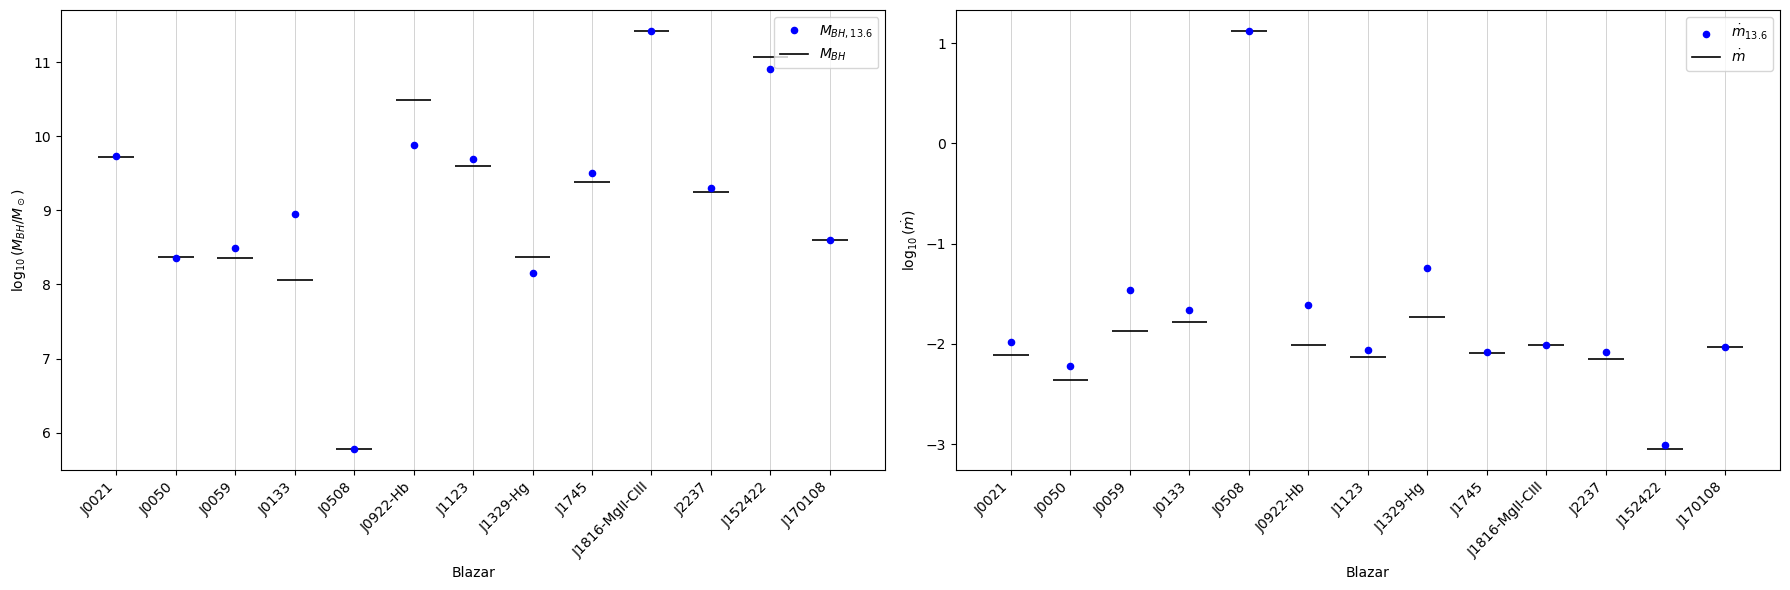

In [60]:
#stampo i due grafici vicini
import matplotlib.pyplot as plt
import numpy as np

point_size = 20
line_width = 1.2
segment_width = 0.30

x = np.arange(len(df13))

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(18, 6)
    )

for xi, mbh in zip(x, df13["M_BH"]):
    ax1.hlines(
    y=np.log10(mbh),
    xmin=xi - segment_width,
    xmax=xi + segment_width,
    color="black",
    linewidth=line_width,
    zorder=2
    )

ax1.scatter(
    x,
    np.log10(df13["M_BH_13.6"]),
    s=point_size,
    color="blue",
    zorder=3,
    label=r"$M_{BH,13.6}$"
    )

ax1.plot(
    [],
    [],
    color="black",
    linewidth=line_width,
    label=r"$M_{BH}$"
    )

for xi in x:
    ax1.axvline(
    x=xi,
    color="gray",
    linewidth=0.6,
    alpha=0.4,
    zorder=0
    )

ax1.set_xticks(x)
ax1.set_xticklabels(
    df13["Blazar"],
    rotation=45,
    ha="right"
    )

ax1.set_ylabel(r"$\log_{10}(M_{BH}/M_\odot)$")
ax1.set_xlabel("Blazar")
ax1.legend()

for xi, mdot in zip(x, df13["m_dot"]):
    ax2.hlines(
    y=np.log10(mdot),
    xmin=xi - segment_width,
    xmax=xi + segment_width,
    color="black",
    linewidth=line_width,
    zorder=2
    )

ax2.scatter(
    x,
    np.log10(df13["m_dot_13.6"]),
    s=point_size,
    color="blue",
    zorder=3,
    label=r"$\dot{m}_{13.6}$"
    )

ax2.plot(
[],
[],
color="black",
linewidth=line_width,
label=r"$\dot{m}$"
)

for xi in x:
    ax2.axvline(
    x=xi,
    color="gray",
    linewidth=0.6,
    alpha=0.4,
    zorder=0
    )

ax2.set_xticks(x)
ax2.set_xticklabels(
    df13["Blazar"],
    rotation=45,
    ha="right"
    )

ax2.set_ylabel(r"$\log_{10}(\dot{m})$")
ax2.set_xlabel("Blazar")
ax2.legend()

plt.tight_layout()
plt.show()